## Obtaining the Efficient Frontier - Part III

*Suggested Answers follow (usually there are multiple ways to solve a problem in Python).*

Ok, let’s continue the exercise from the last lecture.

In [2]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
%matplotlib inline

assets = ['WMT', 'FB']
pf_data = pd.DataFrame()

for a in assets:
    pf_data[a] = yf.download(a, start = '2014-1-1')['Close']

C:\Users\Admin\AppData\Local\Temp\ipykernel_20352\2227741012.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_20352\2227741012.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed


In [3]:
log_returns = np.log(pf_data / pf_data.shift(1))

num_assets = len(assets)

weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights

array([0.4876333, 0.5123667])

Now, estimate the expected Portfolio Return, Variance, and Volatility.

Expected Portfolio Return:

In [4]:
np.sum(weights * log_returns.mean()) * 250

np.float64(0.142731334897431)

Expected Portfolio Variance:

In [5]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

np.float64(0.01168045752022486)

Expected Portfolio Volatility:

In [6]:
np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights)))

np.float64(0.10807616536602721)

***

The rest of this exercise will be a reproduction of what we did in the previous video.

1)	Create two empty lists. Name them pf_returns and pf_volatilites.

In [7]:
pf_returns = []
pf_volatilities = []

2)	Create a loop with 1,000 iterations that will generate random weights, summing to 1, and will append the obtained values for the portfolio returns and the portfolio volatilities to pf_returns and pf_volatilities, respectively.

In [8]:
for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pf_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pf_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))
    
pf_returns, pf_volatilities

([np.float64(0.13863430757744974),
  np.float64(0.14081495508930303),
  np.float64(0.13709664523679965),
  np.float64(0.14048405371758974),
  np.float64(0.14302186051075608),
  np.float64(0.1425940787839552),
  np.float64(0.14254950340911818),
  np.float64(0.1434325951954763),
  np.float64(0.13967485944756342),
  np.float64(0.14643542697632883),
  np.float64(0.14316723062837342),
  np.float64(0.14728234385173966),
  np.float64(0.14441647321480394),
  np.float64(0.14176074543911946),
  np.float64(0.1399582095281277),
  np.float64(0.14026767104111404),
  np.float64(0.13779031971734468),
  np.float64(0.14393821164836054),
  np.float64(0.13589206083485356),
  np.float64(0.1438799451943634),
  np.float64(0.1423543395110301),
  np.float64(0.13855268378463603),
  np.float64(0.13670244287906075),
  np.float64(0.13714930982771228),
  np.float64(0.14170208921921273),
  np.float64(0.13959465464884974),
  np.float64(0.14127442159512832),
  np.float64(0.13929942976916992),
  np.float64(0.1405279529

3)	Transform the obtained lists into NumPy arrays and reassign them to pf_returns and pf_volatilites. Once you have done that, the two objects will be NumPy arrays. 

In [9]:
pf_returns = np.array(pf_returns)
pf_volatilities = np.array(pf_volatilities)

pf_returns, pf_volatilities

(array([0.13863431, 0.14081496, 0.13709665, 0.14048405, 0.14302186,
        0.14259408, 0.1425495 , 0.1434326 , 0.13967486, 0.14643543,
        0.14316723, 0.14728234, 0.14441647, 0.14176075, 0.13995821,
        0.14026767, 0.13779032, 0.14393821, 0.13589206, 0.14387995,
        0.14235434, 0.13855268, 0.13670244, 0.13714931, 0.14170209,
        0.13959465, 0.14127442, 0.13929943, 0.14052795, 0.13932509,
        0.14484303, 0.14303967, 0.13594854, 0.1491324 , 0.14308522,
        0.13594356, 0.14188006, 0.13990705, 0.14167302, 0.13569088,
        0.14273174, 0.14652945, 0.14141105, 0.14419741, 0.14426994,
        0.13679272, 0.13754026, 0.14046905, 0.14020891, 0.14980043,
        0.14291046, 0.14520468, 0.14796007, 0.14186302, 0.1433786 ,
        0.15066977, 0.14378225, 0.13663491, 0.14604173, 0.14757029,
        0.13801668, 0.1412185 , 0.14640803, 0.14877746, 0.14254762,
        0.14002664, 0.14491452, 0.13862619, 0.13822429, 0.14717495,
        0.14260194, 0.14284269, 0.14746908, 0.14

Now, create a dictionary, called portfolios, whose keys are the strings “Return” and “Volatility” and whose values are the NumPy arrays pf_returns and pf_volatilities. 

In [10]:
portfolios = pd.DataFrame({'Return': pf_returns, 'Volatility': pf_volatilities})

In [11]:
portfolios.head()

,Return,Volatility
0,0.138634,0.154682
1,0.140815,0.129456
2,0.137097,0.172829
3,0.140484,0.133234
4,0.143022,0.104930


In [12]:
portfolios.tail()

,Return,Volatility
995,0.142567,0.109873
996,0.139067,0.149619
997,0.137107,0.172711
998,0.134546,0.203349
999,0.149177,0.054593


Finally, plot the data from the portfolios dictionary on a graph. Let the x-axis represent the volatility data from the portfolios dictionary and the y-axis – the data about rates of return. <br />
Organize your chart well and make sure you have labeled both the x- and the y- axes.

Text(0, 0.5, 'Expected Return')

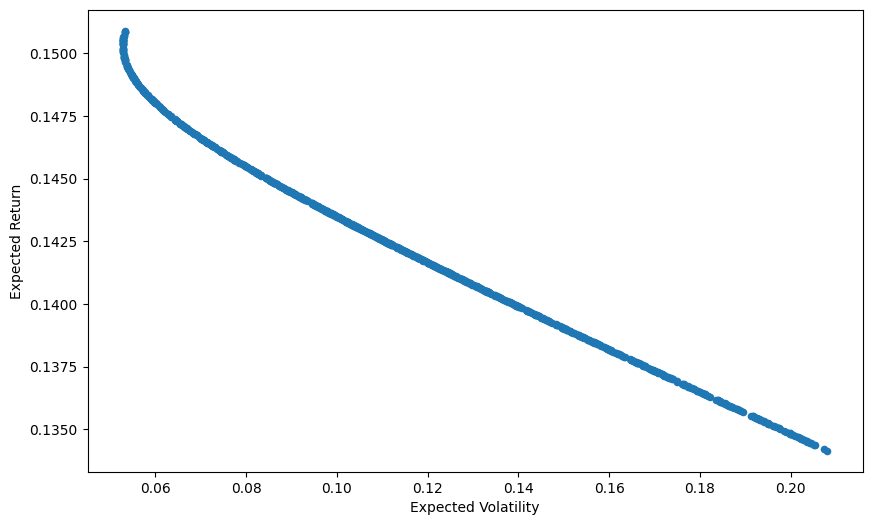

In [13]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10, 6));
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')

******

What do you think would happen if you re-created the Markowitz Efficient Frontier for 3 stocks? The code you have created is supposed to accommodate easily the addition of a third stock, say British Petroleum (‘BP’). Insert it in your data and re-run the code (you can expand the “Cell” list from the Jupyter menu and click on “Run All” to execute all the cells at once!). <br />

How would you interpret the obtained graph? 


In [15]:
assets = ['WMT', 'FB', 'BP']
pf_data = pd.DataFrame()

for a in assets:
    pf_data[a] = yf.download(a, start = '2014-1-1')['Close']

C:\Users\Admin\AppData\Local\Temp\ipykernel_20352\2404337478.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_20352\2404337478.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_20352\2404337478.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pf_data[a] = yf.download(a, start = '2014-1-1')['Close']
[*********************100%***********************]  1 of 1 completed


In [16]:
pf_data.head()

,WMT,FB,BP
Date,,,
2014-01-02,20.850988,NaN,24.222145
2014-01-03,20.782284,NaN,24.166624
2014-01-06,20.666019,NaN,24.232250
2014-01-07,20.729437,NaN,24.509914
2014-01-08,20.565609,NaN,24.600784


In [17]:
log_returns = np.log(pf_data / pf_data.shift(1))

In [18]:
num_assets = len(assets)
num_assets

3

In [19]:
weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights

array([0.19888051, 0.21679647, 0.58432303])

In [20]:
weights[0] + weights[1] + weights[2]

np.float64(1.0)

Expected Portfolio Return:

In [21]:
np.sum(weights * log_returns.mean()) * 250

np.float64(0.07778901237000922)

Expected Portfolio Variance:

In [22]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

np.float64(0.03594410644031894)

Expected Portfolio Volatility:

In [23]:
np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights)))

np.float64(0.18958930993154371)

*****

In [24]:
pfolio_returns = []
pfolio_volatilities = []

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pfolio_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))
    
pfolio_returns = np.array(pfolio_returns)
pfolio_volatilities = np.array(pfolio_volatilities)

pfolio_returns, pfolio_volatilities

(array([0.09957578, 0.07942758, 0.10152122, 0.08754805, 0.09872074,
        0.09755741, 0.12605237, 0.08008289, 0.12301687, 0.09015833,
        0.08504711, 0.08207935, 0.08176655, 0.1070261 , 0.11210611,
        0.09195573, 0.11516091, 0.12862853, 0.10493583, 0.08819165,
        0.13188997, 0.08510936, 0.10426384, 0.07381296, 0.12977346,
        0.11382818, 0.12504907, 0.13522089, 0.08585882, 0.11487935,
        0.10930483, 0.13047137, 0.10248019, 0.09483609, 0.13785388,
        0.13820238, 0.08770762, 0.11409276, 0.07034811, 0.13561628,
        0.13125747, 0.08491729, 0.08304511, 0.0870012 , 0.07907189,
        0.11353324, 0.076867  , 0.04824364, 0.09716332, 0.09371204,
        0.0644749 , 0.11946582, 0.13697313, 0.07233116, 0.14179791,
        0.10679128, 0.06664997, 0.08657259, 0.12866712, 0.09960247,
        0.12217998, 0.13059202, 0.05140283, 0.09256149, 0.10167385,
        0.10901733, 0.08855123, 0.09887828, 0.13434933, 0.11467146,
        0.10217585, 0.10729219, 0.09603505, 0.10

In [25]:
portfolios = pd.DataFrame({'Return': pfolio_returns, 'Volatility': pfolio_volatilities})

Text(0, 0.5, 'Expected Return')

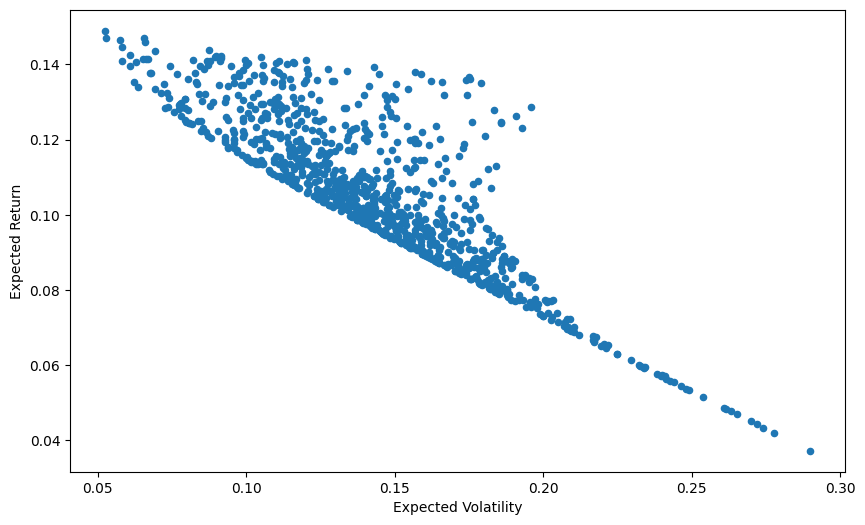

In [26]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10, 6));
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')